In [1]:
import functools
import gurobipy as gp
import inspect

from gurobipy import GRB


def ignore_unused(func):
    sig = inspect.signature(func)
    params = sig.parameters
    accepts_varkw = any(
        p.kind == inspect.Parameter.VAR_KEYWORD for p in params.values()
    )
    allowed = set(params.keys())

    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        if accepts_varkw:
            return func(*args, **kwargs)
        filtered = {k: v for k, v in kwargs.items() if k in allowed}
        return func(*args, **filtered)

    return wrapper


@ignore_unused
def core_to_dev(c: int, LNC: int) -> int:
    return c // LNC


@ignore_unused
def dev_to_rc(dev: int, GRID_W: int, GRID_H: int) -> tuple[int, int]:
    return (dev // GRID_W, dev % GRID_W)


@ignore_unused
def gid(tp: int, dp: int, pp: int, TPN: int, DPN: int) -> int:
    # unique id for triple (tp,dp,pp)
    return (pp * DPN + dp) * TPN + tp


@ignore_unused
def triple_from_gid(g: int, TPN: int, DPN: int) -> tuple[int, int, int]:
    tp = g % TPN
    tmp = g // TPN
    dp = tmp % DPN
    pp = tmp // DPN
    return tp, dp, pp


@ignore_unused
def build_core_adjacency(NDEV: int, GRID_W: int, GRID_H: int, LNC: int):
    """
    Build undirected adjacency on cores based on:
    - intra-device: (2i) <-> (2i+1)
    - inter-device: 4x4 torus neighbors (up/down/left/right with wrap)
        and assume full bipartite connectivity between the two devices' cores.
    Returns:
    E_dir: list of directed edges (x,y) where is_connected(x,y)=True
    E_und: set of undirected edges (min,max)
    """
    ctx = locals().copy()

    und = set()

    # intra-device: fully connect all cores within a device (clique)
    for dev in range(NDEV):
        cores = [dev * LNC + i for i in range(LNC)]
        for i in range(LNC):
            for j in range(i + 1, LNC):
                a, b = cores[i], cores[j]
                und.add((min(a, b), max(a, b)))

    # inter-device torus (full bipartite between devices)
    for dev in range(NDEV):
        r, c = dev_to_rc(dev, **ctx)
        nbrs = [
            ((r - 1) % GRID_H, c),
            ((r + 1) % GRID_H, c),
            (r, (c - 1) % GRID_W),
            (r, (c + 1) % GRID_W),
        ]
        for rr, cc in nbrs:
            dev2 = rr * GRID_W + cc
            if dev2 == dev:
                continue
            for i in range(LNC):
                x = dev * LNC + i
                for j in range(LNC):
                    y = dev2 * LNC + j
                    und.add((min(x, y), max(x, y)))

    E_dir = []
    for a, b in und:
        E_dir.append((a, b))
        E_dir.append((b, a))

    return E_dir, und


def add_pair_must_be_connected(m, a, b, E_DIR, name_prefix="conn"):
    """
    Enforce: the chosen core for group a and chosen core for group b must be adjacent.
    We linearize by selecting exactly one directed edge (x->y) in E_DIR that matches.
    """
    z = {}
    for x, y in E_DIR:
        z[(x, y)] = m.addVar(vtype=GRB.BINARY, name=f"{name_prefix}_{a}_{b}_{x}_{y}")

    # If z(x,y)=1 then a->x and b->y must hold
    for (x, y), zv in z.items():
        m.addConstr(zv <= m._assign[a, x], name=f"{name_prefix}_ubA_{a}_{b}_{x}_{y}")
        m.addConstr(zv <= m._assign[b, y], name=f"{name_prefix}_ubB_{a}_{b}_{x}_{y}")

    # Must pick exactly one feasible adjacent pairing
    m.addConstr(gp.quicksum(z.values()) == 1, name=f"{name_prefix}_one_{a}_{b}")


def solve(
    TPN: int,
    DPN: int,
    PPN: int,
    GRID_W: int = 4,
    GRID_H: int = 4,
    LNC: int = 2,
    tp_device_spread: str = "soft",  # "hard" | "soft" | "none"
):
    NDEV = GRID_W * GRID_H
    NCORES = NDEV * LNC
    assert TPN * DPN * PPN == NCORES

    ctx = locals().copy()

    E_DIR, E_UND = build_core_adjacency(**ctx)

    # Build model
    m = gp.Model("tp_dp_pp_mapping")
    m.Params.OutputFlag = 1  # set 0 if you want silence

    tp_spread_obj_terms = []  # used only if tp_device_spread == "soft"

    G = TPN * DPN * PPN  # 32 groups

    # assign[g, x] = 1 iff group g (a triple) is placed on core x
    assign = m.addVars(G, NCORES, vtype=GRB.BINARY, name="assign")
    m._assign = assign

    # Bijection:
    # each group picks exactly 1 core
    for g in range(G):
        m.addConstr(assign.sum(g, "*") == 1, name=f"group_one_core_{g}")

    # each core hosts exactly 1 group
    for x in range(NCORES):
        m.addConstr(assign.sum("*", x) == 1, name=f"core_one_group_{x}")

    # dev[g, u] = 1 iff group g is on device u
    dev = m.addVars(G, NDEV, vtype=GRB.BINARY, name="dev")
    for g in range(G):
        for u in range(NDEV):
            cores_in_u = [u * LNC + i for i in range(LNC)]
            m.addConstr(
                dev[g, u] == gp.quicksum(assign[g, x] for x in cores_in_u),
                name=f"dev_link_{g}_{u}",
            )

    # ---------- TP constraints ----------
    # For each (dp,pp): tp=0-1-2-3 must form a chain of connected pairs,
    # and all 4 groups lie in the SAME ROW or SAME COLUMN of devices, and use 4 distinct devices.
    for dp in range(DPN):
        for pp in range(PPN):
            gs = [gid(tp, dp, pp, **ctx) for tp in range(TPN)]

            # consecutive tp ranks must be directly connected
            for tp in range(TPN - 1):
                g1 = gid(tp, dp, pp, **ctx)
                g2 = gid(tp + 1, dp, pp, **ctx)
                add_pair_must_be_connected(m, g1, g2, E_DIR, name_prefix="TPedge")

            # if TPN > 2:
            #     add_pair_must_be_connected(m, gid(TPN-1, dp, pp, **ctx), gid(0, dp, pp, **ctx), E_DIR, name_prefix="TPedge")

            if tp_device_spread == "hard":
                # hard: at most 1 TP-rank per device within this (dp,pp) TP group
                for u in range(NDEV):
                    m.addConstr(
                        gp.quicksum(dev[g, u] for g in gs) <= 1,
                        name=f"tp_distinct_dev_dp{dp}_pp{pp}_u{u}",
                    )

            elif tp_device_spread == "soft":
                # soft: allow sharing a device, but maximize how many distinct devices are used
                used_u = m.addVars(NDEV, vtype=GRB.BINARY, name=f"tp_useddev_dp{dp}_pp{pp}")
                for u in range(NDEV):
                    # used_u[u] = OR_{g in gs} dev[g,u]
                    for g in gs:
                        m.addConstr(used_u[u] >= dev[g, u], name=f"tp_useddev_lb_{dp}_{pp}_{g}_{u}")
                    m.addConstr(
                        used_u[u] <= gp.quicksum(dev[g, u] for g in gs),
                        name=f"tp_useddev_ub_{dp}_{pp}_{u}",
                    )
                tp_spread_obj_terms.append(used_u.sum())

            elif tp_device_spread == "none":
                pass

            # # row/col shape choice
            # orient_row = m.addVar(
            #     vtype=GRB.BINARY, name=f"tp_orient_row_dp{dp}_pp{pp}"
            # )  # 1=row, 0=col
            # row_pick = m.addVars(
            #     GRID_H, vtype=GRB.BINARY, name=f"tp_rowpick_dp{dp}_pp{pp}"
            # )
            # col_pick = m.addVars(
            #     GRID_W, vtype=GRB.BINARY, name=f"tp_colpick_dp{dp}_pp{pp}"
            # )

            # m.addConstr(row_pick.sum() == orient_row, name=f"rowpick_sum_dp{dp}_pp{pp}")
            # m.addConstr(
            #     col_pick.sum() == 1 - orient_row, name=f"colpick_sum_dp{dp}_pp{pp}"
            # )

            # # For each g, compute membership in each row/col (linear because dev is one-hot)
            # for g in gs:
            #     # rg[r] = 1 iff g placed in row r
            #     rg = {}
            #     for r in range(GRID_H):
            #         devs_in_row = [r * GRID_W + c for c in range(GRID_W)]
            #         rg[r] = m.addVar(
            #             vtype=GRB.BINARY, name=f"rg_g{g}_dp{dp}_pp{pp}_r{r}"
            #         )
            #         m.addConstr(
            #             rg[r] == gp.quicksum(dev[g, u] for u in devs_in_row),
            #             name=f"rg_link_g{g}_r{r}_dp{dp}_pp{pp}",
            #         )

            #     # cg[c] = 1 iff g placed in col c
            #     cg = {}
            #     for c in range(GRID_W):
            #         devs_in_col = [r * GRID_W + c for r in range(GRID_H)]
            #         cg[c] = m.addVar(
            #             vtype=GRB.BINARY, name=f"cg_g{g}_dp{dp}_pp{pp}_c{c}"
            #         )
            #         m.addConstr(
            #             cg[c] == gp.quicksum(dev[g, u] for u in devs_in_col),
            #             name=f"cg_link_g{g}_c{c}_dp{dp}_pp{pp}",
            #         )

            #     # If orient_row=1, g must be in the picked row: rg[r] <= row_pick[r]
            #     # We relax with big-M to make it inactive when orient_row=0.
            #     for r in range(GRID_H):
            #         m.addConstr(
            #             rg[r] <= row_pick[r] + (1 - orient_row),
            #             name=f"row_enforce_g{g}_r{r}_dp{dp}_pp{pp}",
            #         )
            #     # If orient_row=0, g must be in the picked col: cg[c] <= col_pick[c]
            #     # Relax inactive when orient_row=1.
            #     for c in range(GRID_W):
            #         m.addConstr(
            #             cg[c] <= col_pick[c] + orient_row,
            #             name=f"col_enforce_g{g}_c{c}_dp{dp}_pp{pp}",
            #         )

    # ---------- DP constraints ----------
    # For each (pp,tp): dp0 and dp1 must be connected
    for pp in range(PPN):
        for tp in range(TPN):
            for dp in range(DPN - 1):
                g1 = gid(tp, dp, pp, **ctx)
                g2 = gid(tp, dp + 1, pp, **ctx)
                add_pair_must_be_connected(m, g1, g2, E_DIR, name_prefix="DPedge")

            # if DPN > 2:
            #     add_pair_must_be_connected(m, gid(tp, DPN-1, pp, **ctx), gid(tp, 0, pp, **ctx), E_DIR, name_prefix="DPedge")

    # ---------- PP constraints ----------
    # For each (dp,tp): consecutive pp stages must be connected
    for dp in range(DPN):
        for tp in range(TPN):
            for pp in range(PPN - 1):
                g1 = gid(tp, dp, pp, **ctx)
                g2 = gid(tp, dp, pp + 1, **ctx)
                add_pair_must_be_connected(m, g1, g2, E_DIR, name_prefix="PPedge")

    # Objective: just find any feasible solution (0 objective)
    if tp_device_spread == "soft":
        m.setObjective(gp.quicksum(tp_spread_obj_terms), GRB.MAXIMIZE)
    else:
        m.setObjective(0, GRB.MINIMIZE)

    m.optimize()

    if m.Status != GRB.OPTIMAL and m.Status != GRB.FEASIBLE:
        print("No solution. Status =", m.Status)
        return

    # Print mapping core -> (tp,dp,pp)
    core_map = {}
    for x in range(NCORES):
        for g in range(TPN * DPN * PPN):
            if assign[g, x].X > 0.5:
                tp, dp, pp = triple_from_gid(g, **ctx)
                core_map[x] = (tp, dp, pp)
                break

    print("\n=== core -> (tp,dp,pp) ===")
    for x in range(NCORES):
        print(
            f"core {x:2d} (dev {core_to_dev(x, **ctx):2d} rc={dev_to_rc(core_to_dev(x, **ctx), **ctx)}): {core_map[x]}"
        )

    core_to_rank_mapping = [0] * NCORES
    rank_to_core_mapping = [0] * NCORES
    for core, (tp, dp, pp) in core_map.items():
        r = gid(tp, dp, pp, **ctx)
        core_to_rank_mapping[core] = r
        rank_to_core_mapping[r] = core

    return core_map, core_to_rank_mapping, rank_to_core_mapping

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


@ignore_unused
def visualize_mapping(
    core_map: dict[int, tuple[int, int, int]],
    GRID_W: int = 4,
    GRID_H: int = 4,
    LNC: int = 2,
):
    """
    core_map: { core_id -> (tp, dp, pp) }, core_id in [0..31]
    Layout:
      - 4x4 devices in row-major order (device id = r*4 + c)
      - each device contains 2 cores: core=2*dev (even) and core=2*dev+1 (odd)
    Output: saves PNG and also shows a window if running locally.
    """
    NDEV = GRID_W * GRID_H
    NCORES = NDEV * LNC
    ctx = locals().copy()

    fig, ax = plt.subplots(figsize=(12, 10))

    # --- geometry parameters (tweak if you want) ---
    cell_w, cell_h = 3.2, 2.4  # device box size
    pad_x, pad_y = 0.6, 0.6  # padding between devices
    core_dx = 0.15  # horizontal offset inside device for text alignment
    title_yoff = 0.15

    # axis bounds
    W = GRID_W * (cell_w + pad_x) - pad_x
    H = GRID_H * (cell_h + pad_y) - pad_y
    ax.set_xlim(-0.5, W + 0.5)
    ax.set_ylim(-0.5, H + 0.8)
    ax.set_aspect("equal")
    ax.axis("off")

    # convenience: map (r,c) -> bottom-left coordinate
    def dev_origin(r, c):
        x0 = c * (cell_w + pad_x)
        # matplotlib y grows upward; we want r=0 at top like your figure
        y0 = (GRID_H - 1 - r) * (cell_h + pad_y)
        return x0, y0

    # draw each device
    for dev in range(NDEV):
        r, c = dev_to_rc(dev, **ctx)
        x0, y0 = dev_origin(r, c)

        # device rectangle
        rect = Rectangle((x0, y0), cell_w, cell_h, fill=False, linewidth=2)
        ax.add_patch(rect)

        # diagonal separator to mimic your "two cores" visual
        ax.plot([x0, x0 + cell_w], [y0 + cell_h, y0], linewidth=1)

        # device id label (small)
        ax.text(
            x0 + 0.08,
            y0 + cell_h - 0.22,
            f"Dev {dev} (r{r}c{c})",
            fontsize=10,
            va="top",
        )

        # cores in this device
        c_even = 2 * dev
        c_odd = 2 * dev + 1

        tp, dp, pp = core_map[c_even]
        ax.text(
            x0 + core_dx,
            y0 + cell_h * 0.70,
            f"core {c_even}: (TP{tp},DP{dp},PP{pp})",
            fontsize=11,
            va="center",
        )

        tp, dp, pp = core_map[c_odd]
        ax.text(
            x0 + core_dx,
            y0 + cell_h * 0.30,
            f"core {c_odd}: (TP{tp},DP{dp},PP{pp})",
            fontsize=11,
            va="center",
        )

    ax.text(
        W / 2,
        H + title_yoff,
        "TP/DP/PP assignment on 4x4 Trainium devices (2 cores/device)",
        fontsize=14,
        ha="center",
        va="bottom",
    )

    plt.tight_layout()
    plt.show()


@ignore_unused
def visualize_mapping_core_to_rank(
    core_to_rank_mapping,
    GRID_W: int = 4,
    GRID_H: int = 4,
    LNC: int = 2,
):
    NDEV = GRID_W * GRID_H
    NCORES = NDEV * LNC
    ctx = locals().copy()

    fig, ax = plt.subplots(figsize=(12, 10))

    # --- layout params (保持和你之前的可视化一致即可) ---
    cell_w, cell_h = 3.2, 2.4
    pad_x, pad_y = 0.6, 0.6
    core_dx = 0.15
    title_yoff = 0.15

    W = GRID_W * (cell_w + pad_x) - pad_x
    H = GRID_H * (cell_h + pad_y) - pad_y
    ax.set_xlim(-0.5, W + 0.5)
    ax.set_ylim(-0.5, H + 0.8)
    ax.set_aspect("equal")
    ax.axis("off")

    # r=0 在最上面（和你那张图一致）
    def dev_origin(r, c):
        x0 = c * (cell_w + pad_x)
        y0 = (GRID_H - 1 - r) * (cell_h + pad_y)
        return x0, y0

    for dev in range(NDEV):
        r, c = dev_to_rc(dev, **ctx)
        x0, y0 = dev_origin(r, c)

        # device box + diagonal split
        rect = Rectangle((x0, y0), cell_w, cell_h, fill=False, linewidth=2)
        ax.add_patch(rect)
        ax.plot([x0, x0 + cell_w], [y0 + cell_h, y0], linewidth=1)

        ax.text(
            x0 + 0.08,
            y0 + cell_h - 0.22,
            f"Dev {dev} (r{r}c{c})",
            fontsize=10,
            va="top",
        )

        c_even = 2 * dev
        c_odd = 2 * dev + 1

        ax.text(
            x0 + core_dx,
            y0 + cell_h * 0.70,
            f"core {c_even}: rank {core_to_rank_mapping[c_even]}",
            fontsize=12,
            va="center",
        )

        ax.text(
            x0 + core_dx,
            y0 + cell_h * 0.30,
            f"core {c_odd}: rank {core_to_rank_mapping[c_odd]}",
            fontsize=12,
            va="center",
        )

    ax.text(
        W / 2,
        H + title_yoff,
        "core -> rank assignment on 4x4 Trainium devices (2 cores/device)",
        fontsize=14,
        ha="center",
        va="bottom",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
ctx = dict(TPN=4, DPN=2, PPN=4, GRID_W=4, GRID_H=4, LNC=2)
extra_args = dict(tp_device_spread="soft")

In [79]:
args = {**ctx, **extra_args}
core_map, core_to_rank_mapping, rank_to_core_mapping = solve(**args)

Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) Platinum 8275CL CPU @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Academic license 2773098 - for non-commercial use only - registered to li___@illinois.edu
Optimize a model with 37632 rows, 19968 columns and 96256 nonzeros (Min)
Model fingerprint: 0x384aab08
Model has 0 linear objective coefficients
Variable types: 0 continuous, 19968 integer (19968 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [0e+00, 0e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Presolve removed 33280 rows and 1280 columns
Presolve time: 3.00s
Presolved: 4352 rows, 18688 columns, 60160 nonzeros
Variable types: 0 continuous, 18688 integer (18688 binary)
Found heuristic solution: objective 0.0000000

Explored 0 nodes (0 simpl

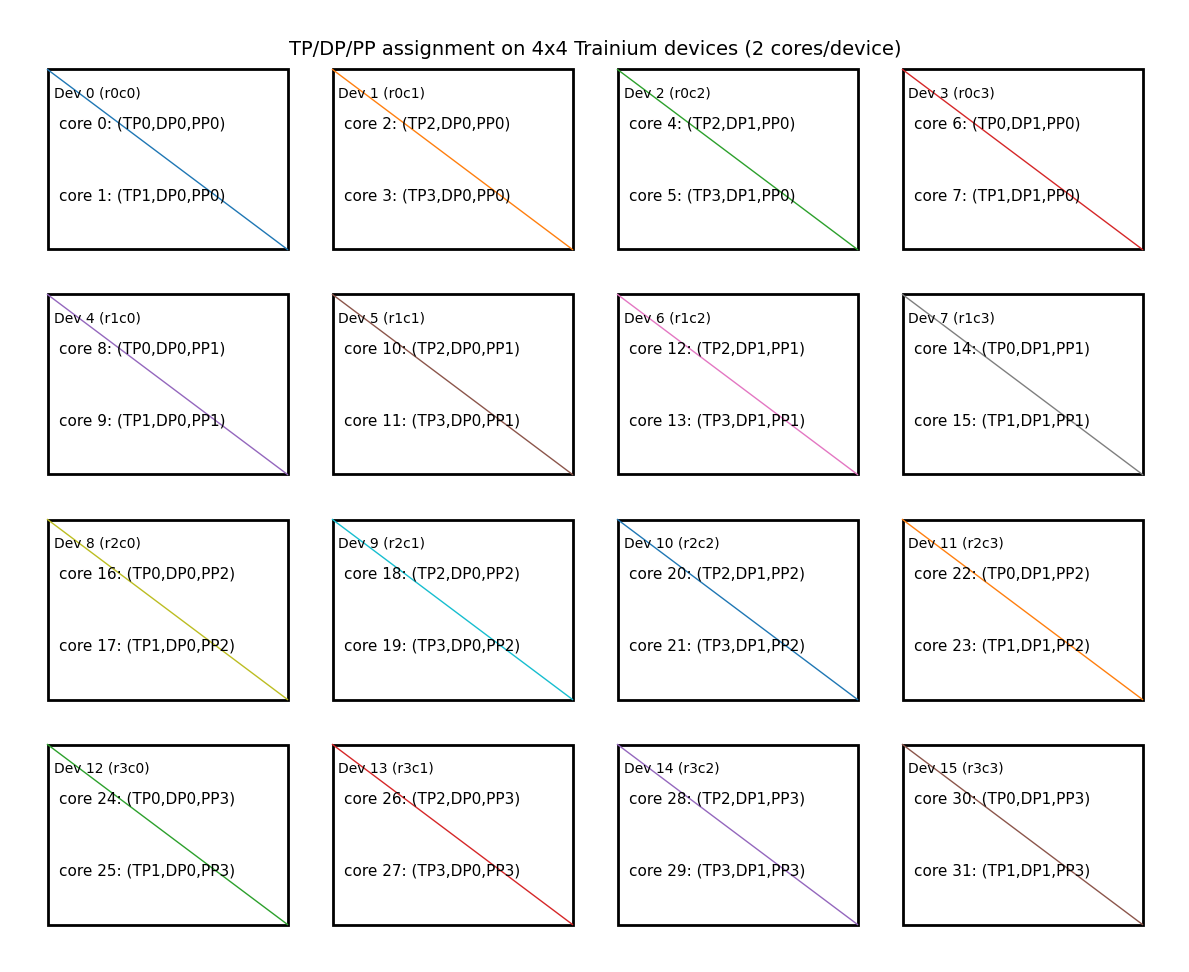

In [11]:
visualize_mapping(core_map, **ctx)

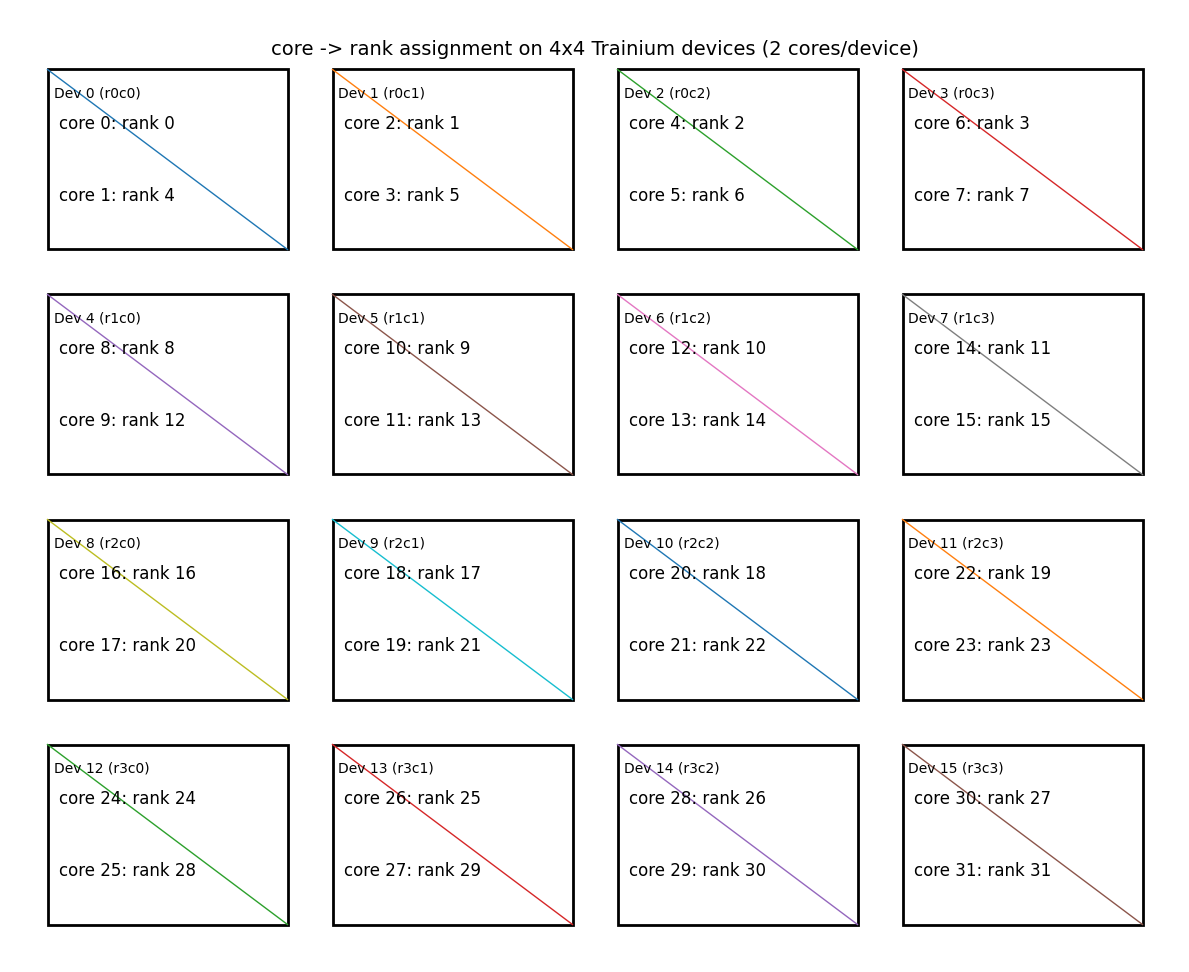

In [80]:
visualize_mapping_core_to_rank(core_to_rank_mapping, **ctx)

In [3]:
import timeit

GRID_W, GRID_H, LNC = 4, 4, 2

NCORES = GRID_W * GRID_H * LNC
solver_overheads = {}
for tp in [1 << i for i in range(NCORES.bit_length())]:
    for dp in [1 << i for i in range((NCORES // tp).bit_length())]:
        pp = NCORES // (tp * dp)
        elapsed = timeit.timeit(
            lambda: solve(
                TPN=tp,
                DPN=dp,
                PPN=pp,
                GRID_W=GRID_W,
                GRID_H=GRID_H,
                LNC=LNC,
                tp_device_spread="soft",
            ),
            number=1,
        )
        solver_overheads[(tp, dp, pp)] = elapsed
        print(f"TP={tp} DP={dp} PP={pp} -> solver overhead: {elapsed:.2f} seconds")

print("\n=== Solver overheads (seconds) ===")
for (tp, dp, pp), overhead in solver_overheads.items():
    print(f"TP={tp} DP={dp} PP={pp} -> {overhead:.2f} seconds")



Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2773098
Academic license 2773098 - for non-commercial use only - registered to li___@illinois.edu
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) Platinum 8275CL CPU @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Academic license 2773098 - for non-commercial use only - registered to li___@illinois.edu
Optimize a model with 19487 rows, 10976 columns and 50272 nonzeros (Max)
Model fingerprint: 0x0edbc234
Model has 512 linear objective coefficients
Variable types: 0 continuous, 10976 integer (10976 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Presolve removed 17408 rows and 1024 columns
Presolve time: 0.23s
